In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from operator import itemgetter
import random
import sys
import time
from IPython.display import clear_output
import math

import utils
import conformal
import evaluate


ModuleNotFoundError: No module named 'conformal'

In [4]:
ratings = pd.read_csv("ml_latest_small_rating.csv",sep=",",names=["user_id","item_id","rating","timestamp"])


In [7]:
USERS = ratings['user_id'].nunique() + 1
ITEMS = ratings['item_id'].nunique() + 1
RATINGS = len(ratings)

profiles_train = [ np.array([],dtype='int') for i in range(USERS) ]
profiles_test = [ np.array([],dtype='int') for i in range(USERS) ]
V = [ np.array([],dtype='int') for i in range(USERS) ]


# Build profiles as lists of items per user
profiles_series = ratings.groupby('user_id')['item_id'].apply(np.array)
profiles = [profiles_series.get(i, np.array([], dtype=int)) for i in range(USERS)]

# Support: frequency of each item
"""support_counts = ratings['item_id'].value_counts()  # <-- keep as Series
support1 = np.zeros(ITEMS, dtype=int)
support1[support_counts.index.to_numpy()] = support_counts.to_numpy()"""
support = np.bincount(ratings['item_id'], minlength=ITEMS)


print(support[1:20])
print(support1[1:20])

print(USERS, ITEMS)

[132  14   1   1   3   1   1   5   1   1   1   3   1   1   1   1   6   4
   1]
[132  14   1   1   3   1   1   5   1   1   1   3   1   1   1   1   6   4
   1]
612 9726


In [9]:
st_time = time.time()

coexistenceCount = np.zeros((ITEMS, ITEMS), dtype=int)
print(coexistenceCount.shape)
for profile in profiles:
    prof = np.array(profile, dtype=int)
    # Build mask for all co-occurrences in this profile
    coexistenceCount[np.ix_(prof, prof)] += 1
#print(coexistenceCount[5][9], coexistenceCount[5][10], time.time()-st_time)    


(9726, 9726)
1 0 2.0934178829193115
1 0 2.186217784881592


In [11]:
import numpy as np

def scoreP(profile, item):
    # Vectorized computation
    pp = coexistenceCount[profile, item] / support[profile]
    
    # Get top-2 values without full sort
    top2 = np.partition(pp, -2)[-2:]  # last 2 largest
    sc = support[item] / USERS
    sc *= np.prod(top2)  # multiply both
    return sc

def scoreR(profile, item, profile_weights):
    # profile_weights is a vector (like profile_wt in your earlier code)
    #print(coexistenceCount.shape, profile_weights.shape)
    pp = profile_weights * coexistenceCount[profile, item] / support[profile]
    
    top2 = np.partition(pp, -2)[-2:]
    sc = support[item] / USERS
    sc *= np.prod(top2)
    return sc


In [13]:
def findLessCount(PP, pp_nv):
    # assumes PP is sorted ascending
    return np.searchsorted(PP, pp_nv, side='right')


In [15]:
def modify(group, val):
    for user in group:
        test_items = np.array(profiles_test[user], dtype=int)
        train_items = np.array(profiles_train[user], dtype=int)

        # update support counts
        support[test_items] += val

        # update coexistence counts in one shot
        coexistenceCount[np.ix_(train_items, test_items)] += val
        coexistenceCount[np.ix_(test_items, train_items)] += val


In [19]:

import numpy as np
import random, time
from operator import itemgetter
from IPython.display import clear_output

def main(G, top_K, Rounds):
    pf_score = np.zeros((6, top_K))   # avg values for 6 eval techniques
    pf_score1 = np.zeros(8)
    baseline_time = 0.0
    CRS_time = 0.0

    # Train/val/test split for each user
    for user in range(USERS):
        prof = np.array(profiles[user], dtype=int)
        #np.random.shuffle(prof)  # faster than random.shuffle
        n = len(prof)
        profiles_train[user] = prof[:n*45//100]
        V[user] = prof[n*45//100:n*60//100]
        profiles_test[user] = prof[n*60//100:]

    run = 0
    while run < Rounds:
        # Sample group
        group = random.sample(range(USERS), G)

        # Compute intersection + size
        sets = [set(profiles[u]) for u in group]
        inter = set.intersection(*sets)
        size = sum(len(profiles[u]) for u in group) / G
        per = (len(inter) / size) * 100

        # Skip groups with too little overlap
        if per < 100 / (2 * G):
            continue

        # Build group_items
        group_train = np.array(list(set().union(*(profiles_train[u] for u in group))))
        group_V = np.array(list(set().union(*(V[u] for u in group))))
        group_items = np.concatenate((group_train, group_V))

       # group_items = set().union(*(profiles_train[u] for u in group))
        # group_items |= set().union(*(V[u] for u in group))
        

        # Modify support/coexistence (leave-one-out style)
        modify(group, -1) ## wrong, needs modification. 

        # --- Build virtual profile Vg ---
        #Vg = {}
        profile_weights = np.zeros(len(group_items))
        for idx, item in enumerate(group_items):
            item_score = 0.0
            for user in group:
                if item in profiles_train[user]:
                    item_score += 1
                else:
                    item_score += scoreP(profiles_train[user], item)
            #Vg[item] = item_score / G
            profile_weights[idx] = item_score / G

            
        # Convert virtual profile to arrays
        profile_items = np.array(list(group_items), dtype=int)
        #profile_weights = np.array([Vg[item] for item in profile_items])

        # Candidate recommendations
        rec_candidates = {
            item: scoreR(profile_items, item, profile_weights)
            for item in range(1, ITEMS)
            if item not in group_items and support[item] > 0
        }

        # Sort candidates
        rec_candidates = dict(sorted(rec_candidates.items(), key=itemgetter(1), reverse=True))

        # Top-K
        recommendations = dict(list(rec_candidates.items())[:top_K])

        # --- Baseline Evaluation ---
        start_time = time.time()
        prec, rec, f1, auc, ndcg, ap, rr = evaluate(group, recommendations, top_K, group_items, rec_candidates, G)
        baseline_time += time.time() - start_time

        pf_score[0] += prec
        pf_score[1] += rec
        pf_score[2] += f1
        pf_score1[0] += auc
        pf_score1[1] += ndcg
        pf_score1[2] += ap
        pf_score1[3] += rr

        # --- Conformal Evaluation ---
        start_time = time.time()
        recommendations1, recommendations2 = conformal(group, G, group_train, group_V, profile_weights, top_K)
        CRS_time += time.time() - start_time

        cprec, crec, cf1, cauc, cndcg, cap, crr = evaluate(group, recommendations1, top_K, group_items, recommendations2, G)
        pf_score[3] += cprec
        pf_score[4] += crec
        pf_score[5] += cf1
        pf_score1[4] += cauc
        pf_score1[5] += cndcg
        pf_score1[6] += cap
        pf_score1[7] += crr

        # Restore support/coexistence
        modify(group, 1)

        run += 1
        clear_output(wait=True)
        print(f"Round {run}")

    # Average over rounds
    pf_score /= Rounds
    pf_score1 /= Rounds
    baseline_time /= Rounds
    CRS_time /= Rounds

    return (pf_score, pf_score1), baseline_time, CRS_time


# Comparison of precision and conformal precision  for group sizes 2

In [17]:
import matplotlib.pyplot as plt
import numpy as np

def plot(data, n, k):
    avg_pf_score, avg_pf_score1 = data
    prec, rec, f1, cprec, crec, cf1 = avg_pf_score
    auc, ndcg, ap, rr, cauc, cndcg, cap, crr = avg_pf_score1

    # Slice top-n if needed
    prec, rec, f1 = prec[:n], rec[:n], f1[:n]
    cprec, crec, cf1 = cprec[:n], crec[:n], cf1[:n]

    # Print summary metrics
    print('AUC:', auc, ' | Conformal AUC:', cauc)
    print('NDCG:', ndcg, ' | Conformal NDCG:', cndcg)
    print('AP:', ap, ' | Conformal AP:', cap)
    print('RR:', rr, ' | Conformal RR:', crr)

    # Helper function for bar plots
    def bar_plot(values1, values2, labels, ylabel, title=""):
        x = np.arange(len(labels))
        width = 0.35
        fig, ax = plt.subplots()
        ax.bar(x - width/2, values1, width, label="GRS")
        ax.bar(x + width/2, values2, width, label="Conformal GRS")
        ax.set_ylabel(ylabel)
        ax.set_xlabel('Top-K' if ylabel.lower() != 'avg_value' else 'Metrics')
        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.legend()
        plt.ylim(min(min(values1), min(values2)) * 0.95, max(max(values1), max(values2)) * 1.05)
        fig.tight_layout()
        plt.show()

    # First plot: overall metrics
    bar_plot(avg_pf_score1[:4], avg_pf_score1[4:], ['AUC', 'NDCG', 'AP', 'RR'], 'avg_value')

    # Top-K plots
    labels_topk = [i+1 for i in range(len(prec))]
    bar_plot(prec, cprec, labels_topk, 'Precision')
    bar_plot(rec, crec, labels_topk, 'Recall')
    bar_plot(f1, cf1, labels_topk, 'F1 Score')


In [18]:
g2, base_time, crs_time =main(2,50,10)
plot(g2,15,50)
print(base_time, crs_time)

NameError: name 'Vg' is not defined

Round 200
auc  0.9553818864604596 cauc  0.9584031088571016
ndcg 0.5232597626617316 cndcg 0.5378635279525713
ap 0.15776896081204556 cap 0.19241052246264187
rr 0.9076015985590457 crr 0.9228677248677252


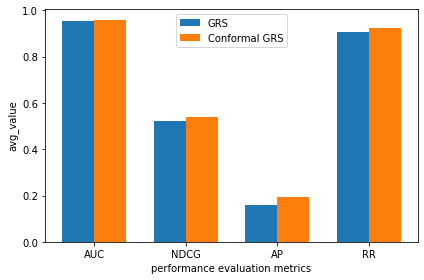

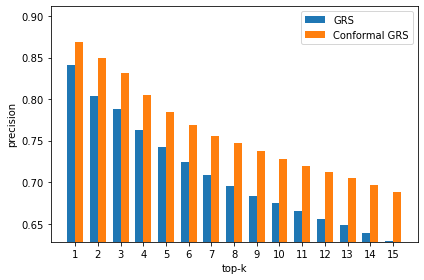

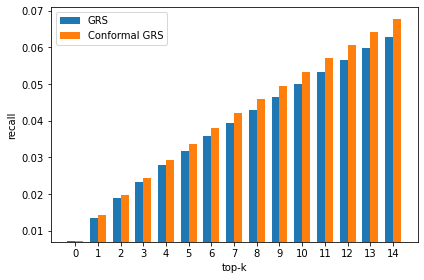

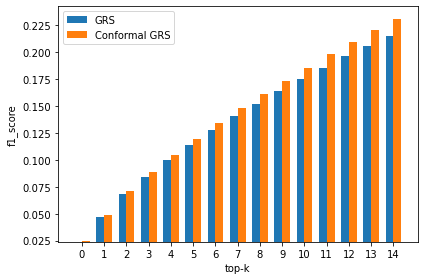

In [14]:
g3=main(3,50,200)
plot(g3,15,50)

Round 200
auc  0.9507354231905606 cauc  0.9530173444141518
ndcg 0.43393664627482775 cndcg 0.4445946911834418
ap 0.10855741534243607 cap 0.13315453034699506
rr 0.8787290088383842 crr 0.8897256469772921


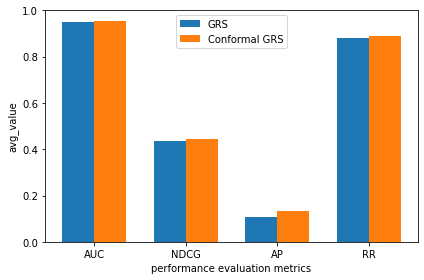

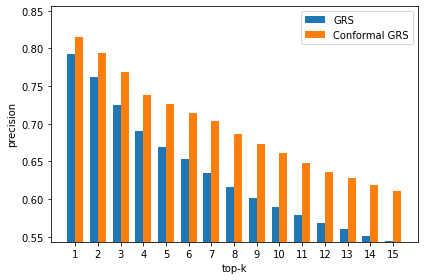

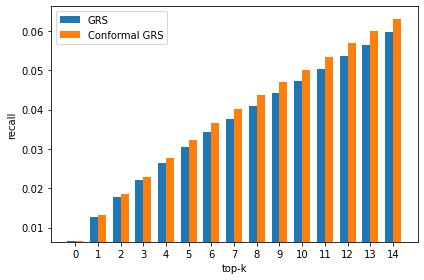

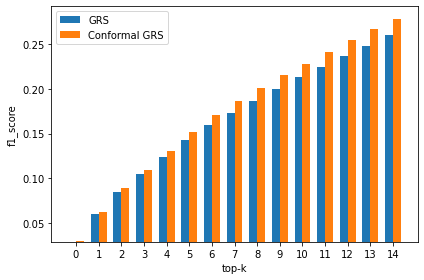

In [15]:
g4 = main(4,50,200) 
plot(g4,15,50)

Round 100
auc  0.946083445659962 cauc  0.9477303747882873
ndcg 0.3674256266276037 cndcg 0.37538372344288284
ap 0.07871320031355768 cap 0.09692863379517855
rr 0.8074042429792432 crr 0.823535087135087


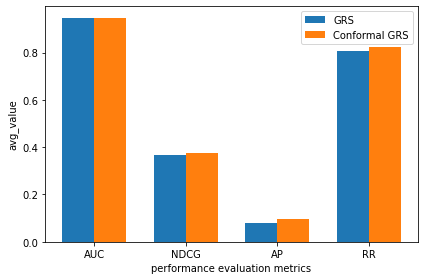

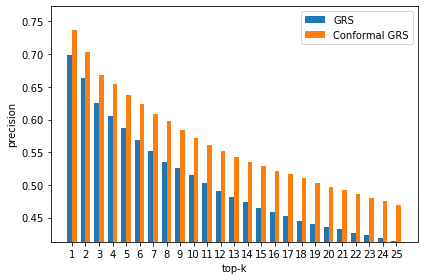

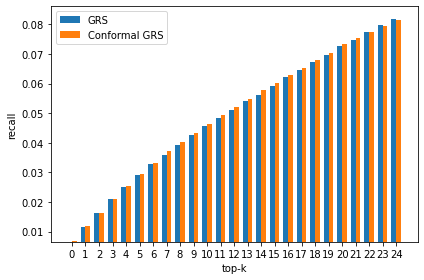

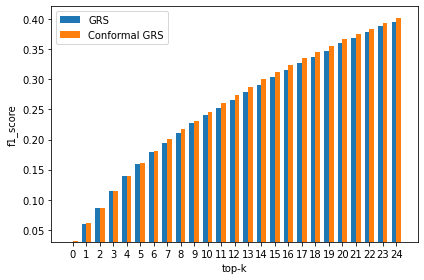

In [16]:
g5 = main(5,50,100)
plot(g5,25,50)

Round 200
auc  0.9410266480268141 cauc  0.9422932677362761
ndcg 0.32410109250024205 cndcg 0.3304524905112566
ap 0.0625927868403104 cap 0.0765154013668597
rr 0.787332452254399 crr 0.8164034568183876


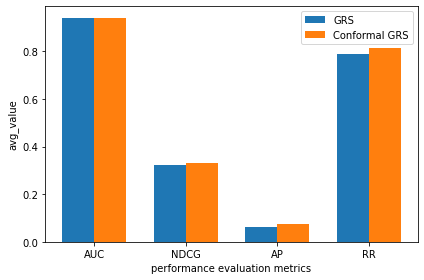

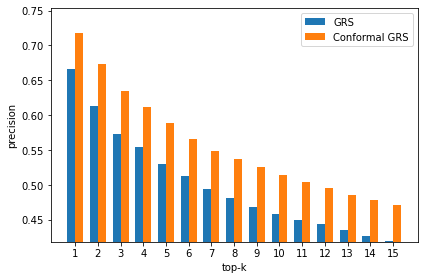

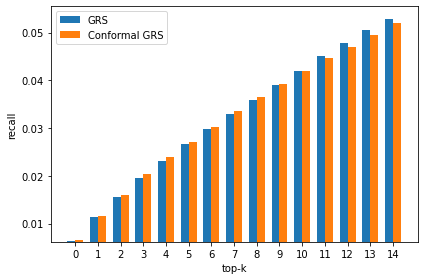

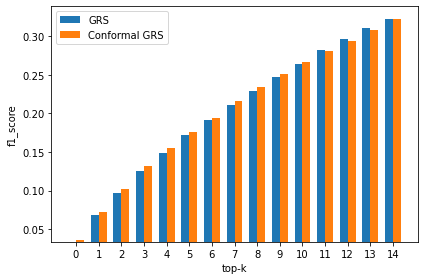

In [17]:
g6=main(6,50,200)
plot(g6,15,50)

auc  0.946083445659962 cauc  0.9477303747882873
ndcg 0.3674256266276037 cndcg 0.37538372344288284
ap 0.07871320031355768 cap 0.09692863379517855
rr 0.8074042429792432 crr 0.823535087135087


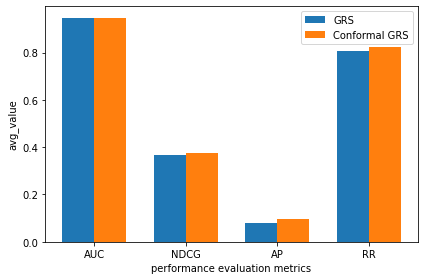

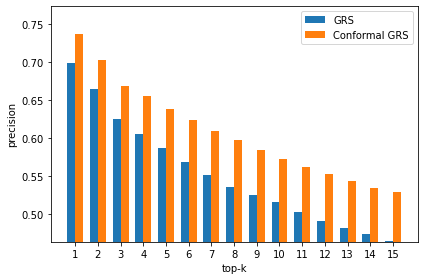

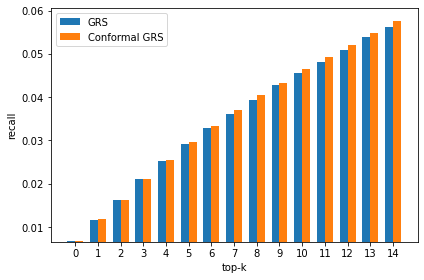

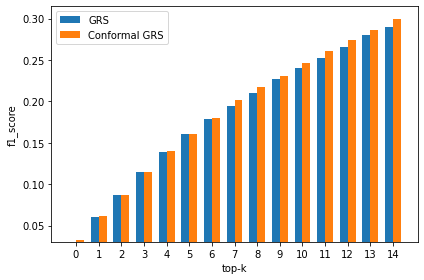

In [18]:
# g5 = main(5,50,100)
plot(g5,15,50)

Round 200
auc  0.9372314804730222 cauc  0.937736089192766
ndcg 0.2878700890578591 cndcg 0.291843988572586
ap 0.04876640245095269 cap 0.05928623128816445
rr 0.7368948587515544 crr 0.7401418387927997


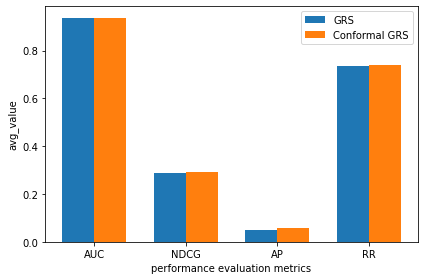

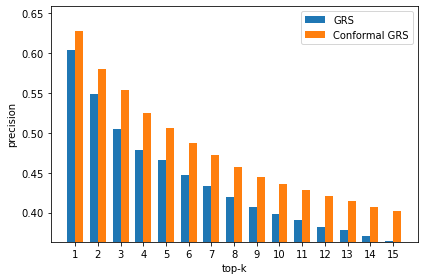

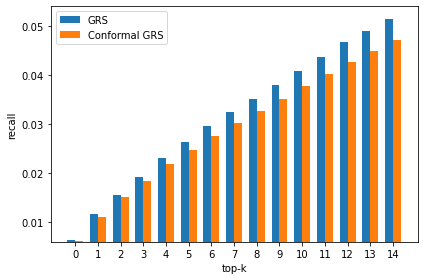

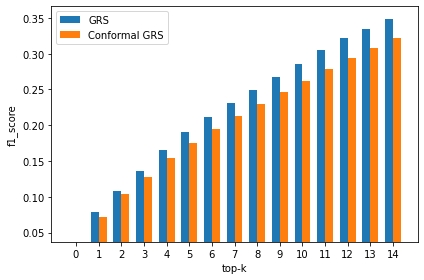

In [12]:
g7=main(7,50,200)
plot(g7,15,50)

In [5]:
!python -V


Python 3.8.5


In [6]:
A = {1, 2, 3}
B = {3, 4, 5}

A |= B
print(np.array(list(A), dtype=int))


[1 2 3 4 5]
